# 07 · Calibration: measuring interaction matrices with zonal, Hadamard and zonal-fast patterns

**Who this is for:** you calibrate an AO system and want to choose the poke patterns that give the best interaction matrix (IM) for your time budget, then turn it into a modal reconstructor.

## The problem

The IM `D` maps DM commands to wavefront-sensor (WFS) measurements: `slopes = D @ commands`. You measure it by applying known command patterns `P` (one per WFS frame, amplitude `a`) and recording the slopes:

$$ Y = a\, D P + \text{noise} \quad\Rightarrow\quad \hat D = Y P^{+} / a .$$

The choice of `P` decides how many frames you need and how much noise ends up in `D̂`. This notebook builds a small simulated system and compares the options.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import aobasis

plt.rcParams["figure.dpi"] = 80
rng = np.random.default_rng(1)

## A toy AO system

- **DM:** 225 actuators with Gaussian influence functions, including a ring just outside a 10 m pupil (as in [06](06_influence_functions.ipynb)).
- **WFS:** a Shack-Hartmann-like sensor with 12 × 12 subapertures. Each measures the mean x and y phase gradient over its pixels, and subapertures at least half illuminated are kept.

The sensor below is a deliberately simple linear model. Replace it with your own WFS model, or measured data.

225 actuators, 224 slopes


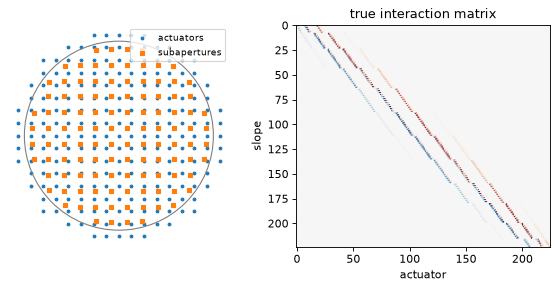

In [2]:
D_TEL, N_PIX = 10.0, 48
points = aobasis.make_pupil_points(D_TEL, N_PIX)
pitch = D_TEL / 15
actuators = aobasis.make_circular_actuator_grid(D_TEL + 2 * pitch, pitch=pitch)
influence = aobasis.gaussian_influence_functions(actuators, points, pitch=pitch)


def slope_sensor(points, n_sub, n_pix=N_PIX, diameter=D_TEL):
    """(2 n_valid, n_points) matrix of mean x/y gradients per subaperture, and subaperture centres."""
    pixel = diameter / n_pix
    col, row = np.rint(points / pixel + 0.5 * (n_pix - 1)).astype(int).T
    size = n_pix // n_sub
    rows, centres = [], []
    for sy in range(n_sub):
        for sx in range(n_sub):
            inside = np.flatnonzero((col // size == sx) & (row // size == sy))
            if len(inside) < size * size / 2:
                continue  # less than half illuminated
            for local in (col[inside] % size, row[inside] % size):  # x then y gradient
                high, low = inside[local >= size // 2], inside[local < size // 2]
                g = np.zeros(len(points))
                if len(high) and len(low):
                    g[high], g[low] = 1 / len(high), -1 / len(low)
                rows.append(g / (size / 2 * pixel))
                centres.append(points[inside].mean(axis=0))
    return np.array(rows), np.array(centres)


wfs, centres = slope_sensor(points, n_sub=12)
D_true = wfs @ influence  # the interaction matrix we want to measure
n_act, n_meas = len(actuators), len(wfs)
print(f"{n_act} actuators, {n_meas} slopes")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].scatter(*actuators.T, s=6, label="actuators")
axes[0].scatter(*centres[::2].T, s=12, marker="s", label="subapertures")
axes[0].add_patch(plt.Circle((0, 0), D_TEL / 2, fill=False, color="0.5"))
axes[0].set_aspect("equal"); axes[0].legend(fontsize=8, loc="upper right"); axes[0].axis("off")
axes[1].imshow(D_true, aspect="auto", cmap="RdBu_r")
axes[1].set_xlabel("actuator"); axes[1].set_ylabel("slope"); axes[1].set_title("true interaction matrix")
plt.show()

Each frame adds independent slope noise. `measure(P)` applies the patterns at amplitude `a` and returns the noisy slopes divided by `a`. The `error` is the relative Frobenius error of an IM estimate.

In [3]:
amplitude = 0.05
noise = 0.002 * np.abs(D_true).max()  # slope noise per frame


def measure(patterns, repeats=1):
    frames = [D_true @ patterns * amplitude + noise * rng.standard_normal((n_meas, patterns.shape[1])) for _ in range(repeats)]
    return np.mean(frames, axis=0) / amplitude


def error(D_hat):
    return np.linalg.norm(D_hat - D_true) / np.linalg.norm(D_true)

## Zonal: poke one actuator per frame

`P = I`, so `n_act` frames, and each column of `D̂` comes straight from one frame. Simple, but each frame carries the signal of a single actuator.

In [4]:
D_zonal = measure(aobasis.ZonalBasisGenerator(actuators).generate(n_act))
print(f"zonal:    {n_act} frames, error {error(D_zonal):.3f}")

zonal:    225 frames, error 0.519


## Hadamard: every actuator in every frame

With ±1 Hadamard patterns, every frame contains every actuator at full amplitude. Because the patterns are orthogonal, `D̂ = Y Hᵀ / N` separates them again, and each actuator's response is effectively averaged over all `N` frames. The noise in `D̂` falls by about `√N` relative to zonal, for the same number of frames: the **multiplex advantage**.

`construction="smallest"` uses the smallest Hadamard matrix that fits (order 228 for 225 actuators), so the truncated patterns stay nearly orthogonal.

In [5]:
H = aobasis.HadamardBasisGenerator(actuators).generate(n_act, construction="smallest")
D_hadamard = measure(H) @ np.linalg.pinv(H)
print(f"Hadamard: {n_act} frames, error {error(D_hadamard):.3f}   (zonal / Hadamard = {error(D_zonal) / error(D_hadamard):.1f}, √N = {np.sqrt(n_act):.1f})")

Hadamard: 225 frames, error 0.055   (zonal / Hadamard = 9.4, √N = 15.0)


The gain is a bit below √N here because the patterns are truncated, and some actuators barely touch the pupil, so their responses are near the noise floor whatever you do.

Hadamard needs the system to be **linear**: all actuators move at once, so the DM's total stroke and the WFS's dynamic range must accommodate the sum. Reduce `amplitude` if needed.

## Zonal fast: poke well-separated actuators together

If actuators far enough apart produce responses in *different* subapertures, you can poke them in the same frame and tell their responses apart by location. `ZonalFastBasisGenerator(min_distance=d)` groups actuators so that pokes in a pattern are at least `d` apart.

To separate the responses, each slope in a frame is assigned to the nearest poked actuator, if it's within a **support radius** `ρ` of it. Two conditions keep the estimate exact:

- `ρ` must cover each actuator's response footprint;
- `d ≥ 2ρ`, so footprints in the same frame don't overlap.

How far does one actuator's response reach?

In [6]:
distance = np.linalg.norm(centres[:, None, :] - actuators[None], axis=-1)  # (n_meas, n_act)
for rho in (1.0, 1.5, 2.0, 2.5):
    truncated = np.where(distance <= rho * pitch, D_true, 0.0)
    print(f"keeping slopes within {rho} pitch of each actuator loses {error(truncated):.2%} of the IM")

keeping slopes within 1.0 pitch of each actuator loses 42.45% of the IM
keeping slopes within 1.5 pitch of each actuator loses 9.77% of the IM
keeping slopes within 2.0 pitch of each actuator loses 0.64% of the IM
keeping slopes within 2.5 pitch of each actuator loses 0.03% of the IM


A support of 2.5 pitch is essentially exact, so `min_distance` should be about 5 pitch.

In [7]:
def zonal_fast_estimate(patterns, Y, rho):
    D_hat = np.zeros_like(D_true)
    for k in range(patterns.shape[1]):
        members = np.flatnonzero(patterns[:, k])
        d = distance[:, members]
        nearest = members[np.argmin(d, axis=1)]
        close = d.min(axis=1) <= rho
        D_hat[np.flatnonzero(close), nearest[close]] = Y[close, k]
    return D_hat


print(" min_distance  frames  noise-free error  noisy error")
for factor in (3, 4, 5, 6):
    P = aobasis.ZonalFastBasisGenerator(actuators, min_distance=factor * pitch).generate()
    rho = min(2.5, factor / 2) * pitch
    exact = zonal_fast_estimate(P, D_true @ P, rho)
    noisy = zonal_fast_estimate(P, measure(P), rho)
    print(f"  {factor} pitch     {P.shape[1]:4}        {error(exact):.4f}         {error(noisy):.3f}")

 min_distance  frames  noise-free error  noisy error
  3 pitch        9        0.1076         0.142
  4 pitch       15        0.0067         0.127
  5 pitch       23        0.0003         0.152
  6 pitch       34        0.0003         0.149


Too small a `min_distance` and the footprints overlap (cross-talk). At 5 pitch the estimate is exact without noise and needs **23 frames instead of 225**. With noise it's already much better than zonal: each slope is still measured once, but slopes far from an actuator are set to zero, which uses the prior knowledge that the response is local.

## Same time budget

With 225 frames available, zonal fast can repeat its 23 patterns 9 times and average:

In [8]:
P = aobasis.ZonalFastBasisGenerator(actuators, min_distance=5 * pitch).generate()
rows = [("zonal", n_act, D_zonal), ("Hadamard", n_act, D_hadamard)]
for repeats in (1, 3, 9):
    rows.append((f"zonal fast ×{repeats}", repeats * P.shape[1], zonal_fast_estimate(P, measure(P, repeats), 2.5 * pitch)))
estimates = {name: D_hat for name, _, D_hat in rows}
for name, frames, D_hat in rows:
    print(f"{name:<15} {frames:4} frames   error {error(D_hat):.3f}")

zonal            225 frames   error 0.519
Hadamard         225 frames   error 0.055
zonal fast ×1     23 frames   error 0.150
zonal fast ×3     69 frames   error 0.087
zonal fast ×9    207 frames   error 0.050


Hadamard and repeated zonal fast reach about the same accuracy for the same time. Zonal fast tolerates nonlinearity better, since only a few actuators move at once, and its patterns can stop early if you're short of time.

## From the zonal IM to modal control

For control you usually work in a modal basis. With an M2C (here, KL modes of this DM), the **modal IM** is `D̂ @ M2C`. A least-squares reconstructor is its pseudo-inverse, giving modal coefficients from slopes. The commands to apply are `M2C @ coefficients`.

To see what calibration quality means for correction, apply each reconstructor to random turbulence and measure the residual wavefront left after one correction step:

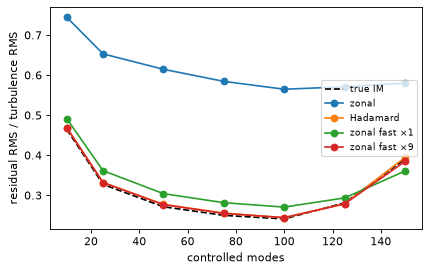

In [9]:
dmkl = aobasis.DMKLBasisGenerator(actuators, points, influence, fried_parameter=0.15, outer_scale=25.0)
m2c = dmkl.generate(150, ignore_piston=True)

pupil_kl = aobasis.KLBasisGenerator(points, fried_parameter=0.15, outer_scale=25.0)
screen_modes = pupil_kl.generate(400, ignore_piston=True)
screens = screen_modes @ (rng.standard_normal((400, 30)) * np.sqrt(pupil_kl.eigenvalues)[:, None])
slopes = wfs @ screens


def residual(D_hat, n_modes):
    reconstructor = np.linalg.pinv(D_hat @ m2c[:, :n_modes], rcond=1e-3)
    commands = m2c[:, :n_modes] @ (reconstructor @ slopes)
    left = screens - influence @ commands
    left -= left.mean(axis=0)  # piston is invisible and irrelevant
    return np.sqrt(np.mean(left**2) / np.mean((screens - screens.mean(axis=0)) ** 2))


n_list = (10, 25, 50, 75, 100, 125, 150)
plt.figure(figsize=(6, 3.6))
plt.plot(n_list, [residual(D_true, n) for n in n_list], "k--", label="true IM")
for name in ("zonal", "Hadamard", "zonal fast ×1", "zonal fast ×9"):
    plt.plot(n_list, [residual(estimates[name], n) for n in n_list], "o-", label=name)
plt.xlabel("controlled modes")
plt.ylabel("residual RMS / turbulence RMS")
plt.legend(fontsize=8, loc="center right")
plt.show()

What the plot shows:

- **Calibration noise costs correction.** The noisy zonal IM leaves more than twice the residual of a Hadamard or repeated zonal-fast IM, which are indistinguishable from the true IM.
- **More modes isn't always better.** Past about 100 modes the residual rises again, *even with the true IM*. The sensor (12 subapertures across) can't distinguish the highest DM modes, so the reconstructor amplifies noise and aliasing into them. Control only the modes your WFS sees, and check the modal IM's singular values.
- The floor (about 0.24 here) is the toy system's fitting and aliasing error, not a property of the bases.

## Practical tips

- **Push-pull.** Measure each pattern at `+a` and `−a` and take half the difference. That cancels static offsets and first-order nonlinearity, at twice the frames.
- **Random signs.** `ZonalFastBasisGenerator.generate(signs="random")` gives each poke a random ±1, which spreads stroke and keeps the patterns zero-mean on average. Divide the measured slopes by the same signs.
- **Piston and waffle.** Calibrate the full zonal IM, then build the M2C with `ignore_piston=True` (and `remove=` for waffle, if your WFS is blind to it). The reconstructor then never commands them.
- **Save the M2C you calibrated with** (`save` or `save_fits`). Its parameters and options are stored with it, and KL modes are reproducible across machines; see [08](08_saving_and_sharing.ipynb).